<a href="https://colab.research.google.com/github/mateoveega/MCMC-MonteCarlo-TFG/blob/main/cap3/platano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import os
import sys
import importlib

repo_name = 'MCMC-MonteCarlo-TFG'
repo_url = f'https://github.com/mateoveega/{repo_name}.git'
repo_path = f'/content/{repo_name}'

if not os.path.exists(repo_path):
    !git clone {repo_url}
else:
    %cd {repo_path}
    !git pull
    %cd /content

if repo_path not in sys.path:
    sys.path.append(repo_path)

import aux
importlib.reload(aux)
from aux import log_platano, pdf_platano

import samplers
importlib.reload(samplers)
from samplers import box_muller, random_walk_metropolis

from google.colab import files
import numpy as np
import matplotlib.pyplot as plt



/content/MCMC-MonteCarlo-TFG
Already up to date.
/content


In [14]:
d = 2
num_iteraciones = 20000
t0 = 500
c = 0.4
sd = c * ((2.38**2) / d)
epsilon = 1e-5

semilla_box = 1
semilla_unif = 2

muestras_Z = box_muller(
  d,
  num_iteraciones,
  semilla_box
)

generador_unif = np.random.default_rng(semilla_unif)
muestras_U = generador_unif.random(num_iteraciones)

muestras = np.zeros((num_iteraciones, d))
muestras[0] = np.array([0.0, 0.0])

cov_t = np.eye(d) * 0.1
cov_empirica = np.zeros((d, d))
media_t = muestras[0].copy()

aceptados = 0

for t in range(1, num_iteraciones):
    x_anterior = muestras[t-1]

    if t > t0:
        diferencia = x_anterior - media_t
        media_t = media_t + diferencia / t
        cov_empirica = ((t - 1) / t) * cov_empirica + (1 / t) * np.outer(diferencia, x_anterior - media_t)
        cov_t = sd * cov_empirica + sd * epsilon * np.eye(d)

    L = np.linalg.cholesky(cov_t)
    y_candidato = x_anterior + L @ muestras_Z[t]

    log_alfa = log_platano(y_candidato) - log_platano(x_anterior)

    if np.log(muestras_U[t]) < log_alfa:
        muestras[t] = y_candidato
        aceptados += 1
    else:
        muestras[t] = x_anterior

print(f"Tasa de aceptacion AM: {aceptados / num_iteraciones:.4f}")

Tasa de aceptacion AM: 0.2687


/tmp/ipykernel_15595/3139250691.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


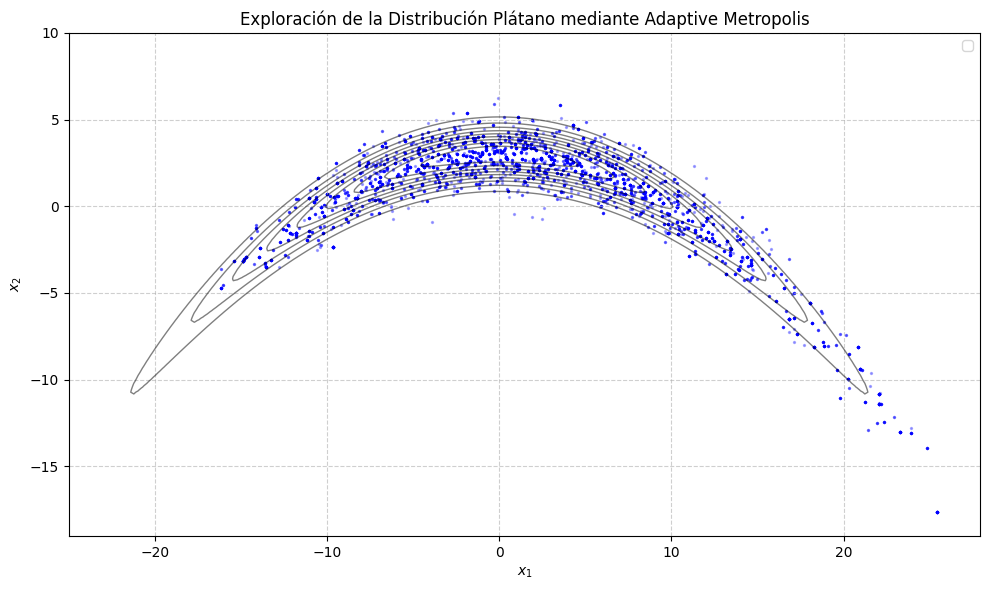

In [15]:
calentamiento = 1000
muestras_validas = muestras[calentamiento:]

num_pasos_grafico = 5000
fin_grafico = calentamiento + num_pasos_grafico

malla_x = np.linspace(-25, 25, 200)
malla_y = np.linspace(-15, 10, 200)
X, Y = np.meshgrid(malla_x, malla_y)
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = pdf_platano([X[i, j], Y[i, j]])

plt.figure(figsize=(10, 6))

plt.contour(X, Y, Z, levels=10, colors='black', alpha=0.5, linewidths=1)

plt.scatter(muestras_validas[calentamiento:fin_grafico, 0], muestras_validas[calentamiento:fin_grafico, 1], s=2, alpha=0.3, color='blue')

plt.title('Exploración de la Distribución Plátano mediante Adaptive Metropolis')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('BANANA.pdf')
plt.show()

In [16]:
num_iteraciones = 20000
posicion_inicial = [0.0, 0.0]

sigma_corta = 0.5
muestras_corta, acep_corta = random_walk_metropolis(
    pdf_platano,
    num_iteraciones,
    posicion_inicial,
    sigma_corta
)

sigma_media = 4.0
muestras_media, acep_media = random_walk_metropolis(
    pdf_platano,
    num_iteraciones,
    posicion_inicial,
    sigma_media
)

sigma_larga = 7.0
muestras_larga, acep_larga = random_walk_metropolis(
    pdf_platano,
    num_iteraciones,
    posicion_inicial,
    sigma_larga
)

print(f"RWM Isotrópico (sigma={sigma_corta}): Tasa de aceptación = {acep_corta:.4f}")
print(f"RWM Isotrópico (sigma={sigma_media}): Tasa de aceptación = {acep_media:.4f}")
print(f"RWM Isotrópico (sigma={sigma_larga}): Tasa de aceptación = {acep_larga:.4f}")

RWM Isotrópico (sigma=0.5): Tasa de aceptación = 0.8169
RWM Isotrópico (sigma=4.0): Tasa de aceptación = 0.2610
RWM Isotrópico (sigma=7.0): Tasa de aceptación = 0.1468


<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:37: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_15595/3320976926.py:17: SyntaxWarning: invalid escape sequence '\s'
  axes[0].set_title(f'Colapso por confinamiento local ($\sigma={sigma_corta}$)', fontsize=18)
/tmp/ipykernel_15595/3320976926.py:27: SyntaxWarning: invalid escape sequence '\s'
  axes[1].set_title(f'Calibración Manual Óptima ($\sigma={sigma_media}$)', fontsize=18)
/tmp/ipykernel_15595/3320976926.py:37: SyntaxWarning: invalid escape sequence '\s'
  axes[2].set_title(f'Rechazo Sistemático ($\sigma={sigma_larga}$)', fontsize=18)
/tmp/ipykernel_15595/3320976926.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() 

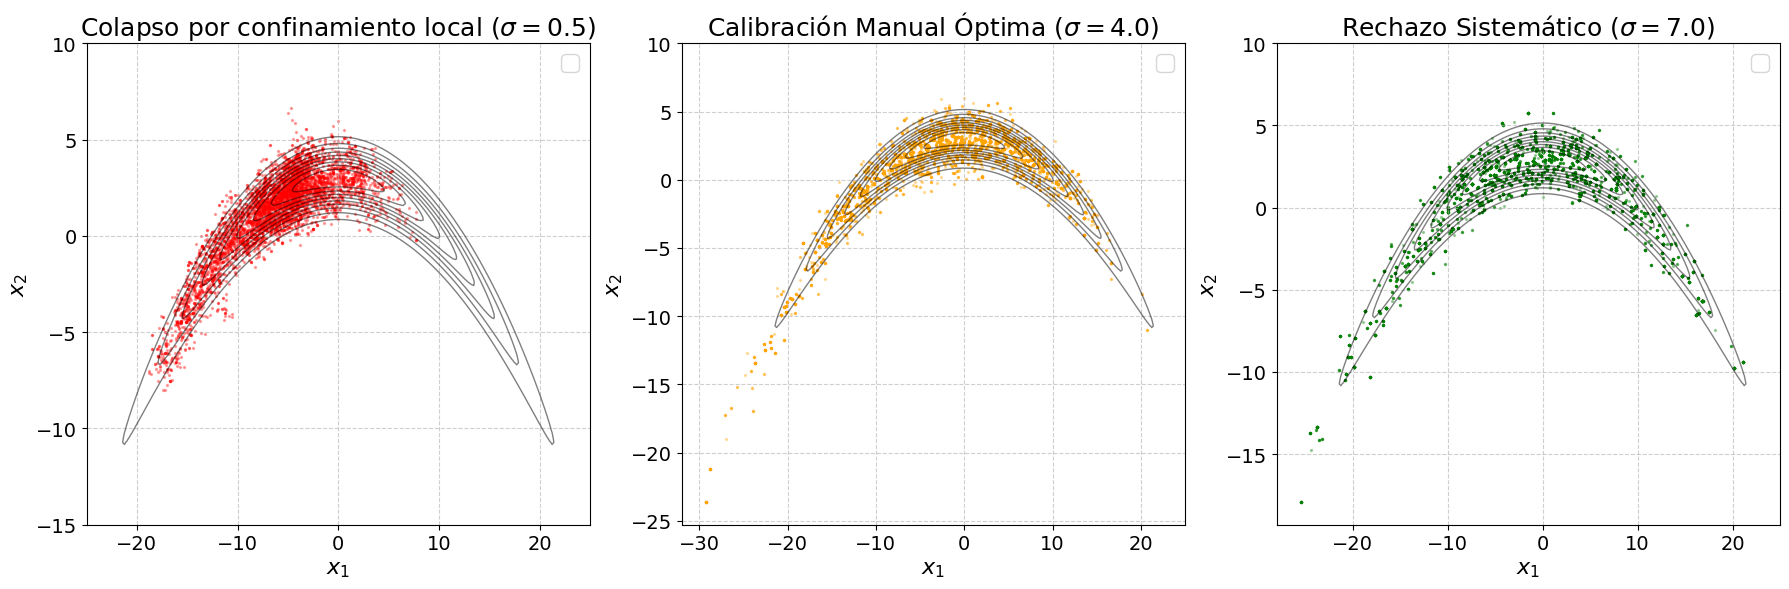

In [17]:
malla_x = np.linspace(-25, 25, 200)
malla_y = np.linspace(-15, 10, 200)
X, Y = np.meshgrid(malla_x, malla_y)
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = pdf_platano([X[i, j], Y[i, j]])

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

num_pasos_grafico = 5000
fin_grafico = calentamiento + num_pasos_grafico

axes[0].contour(X, Y, Z, levels=10, colors='black', alpha=0.5, linewidths=1)
axes[0].scatter(muestras_corta[calentamiento:fin_grafico, 0], muestras_corta[calentamiento:fin_grafico, 1],
                s=2, alpha=0.3, color='red')
axes[0].set_title(f'Colapso por confinamiento local ($\sigma={sigma_corta}$)', fontsize=18)
axes[0].set_xlabel('$x_1$', fontsize=16)
axes[0].set_ylabel('$x_2$', fontsize=16)
axes[0].legend(fontsize=16)
axes[0].tick_params(axis='both', labelsize=14)
axes[0].grid(True, linestyle='--', alpha=0.6)

axes[1].contour(X, Y, Z, levels=10, colors='black', alpha=0.5, linewidths=1)
axes[1].scatter(muestras_media[calentamiento:fin_grafico, 0], muestras_media[calentamiento:fin_grafico, 1],
                s=2, alpha=0.3, color='orange')
axes[1].set_title(f'Calibración Manual Óptima ($\sigma={sigma_media}$)', fontsize=18)
axes[1].set_xlabel('$x_1$', fontsize=16)
axes[1].set_ylabel('$x_2$', fontsize=16)
axes[1].legend(fontsize=16)
axes[1].tick_params(axis='both', labelsize=14)
axes[1].grid(True, linestyle='--', alpha=0.6)

axes[2].contour(X, Y, Z, levels=10, colors='black', alpha=0.5, linewidths=1)
axes[2].scatter(muestras_larga[calentamiento:fin_grafico, 0], muestras_larga[calentamiento:fin_grafico, 1],
                s=2, alpha=0.3, color='green')
axes[2].set_title(f'Rechazo Sistemático ($\sigma={sigma_larga}$)', fontsize=18)
axes[2].set_xlabel('$x_1$', fontsize=16)
axes[2].set_ylabel('$x_2$', fontsize=16)
axes[2].legend(fontsize=16)
axes[2].tick_params(axis='both', labelsize=14)
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('BANANA_rwm.pdf')
plt.show()

In [18]:
files.download("BANANA.pdf")
files.download("BANANA_rwm.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>